In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d,gaussian_filter
import pickle
from skimage import io, filters
import glob
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import psutil
from brainsss import brain_utils

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
fly_num = 'fly_209'

tf_path = 'temp_filter/functional_channel_2_moco_warp_blurred_hpf_dff_filtered.h5'
dff_path = 'dff/functional_channel_2_moco_warp_blurred_hpf_dff.h5'

func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
timestamp_file = "warp/timestamps_warp.h5"


tf_dir = os.path.join(func_path, tf_path)
dff_dir = os.path.join(func_path, dff_path)
ts_dir = os.path.join(func_path, timestamp_file)


In [3]:
%%time
with h5py.File(tf_dir, 'r') as hf:
        brain = hf['brain'][:]
        ts = hf['time_stamps'][:]
        dimsb = np.shape(brain)
        dimst = np.shape(ts)
print(f"Brain shape is {dimsb}, time stamp shape is {dimst}")

Brain shape is (314, 146, 91, 1039), time stamp shape is (314, 146, 91, 1039)
CPU times: user 0 ns, sys: 21.6 s, total: 21.6 s
Wall time: 2min 41s


In [4]:
%%time
start=1500
end=1600
with h5py.File(dff_dir, 'r') as ff:
        dff = ff['data']
        dff=dff[...,start:end]
        dimsdf = np.shape(dff)
        print(f"Data shape is {dimsdf}")

Data shape is (314, 146, 91, 100)
CPU times: user 310 ms, sys: 10.6 s, total: 11 s
Wall time: 4min 11s


In [5]:
%%time
with h5py.File(ts_dir, 'r') as tf:
        t = tf['data']
        t=t[...,start:end]
        dimst=np.shape(t)
        print(f"Data shape is {dimst}")

Data shape is (314, 146, 91, 100)
CPU times: user 336 ms, sys: 11.7 s, total: 12.1 s
Wall time: 5min 7s


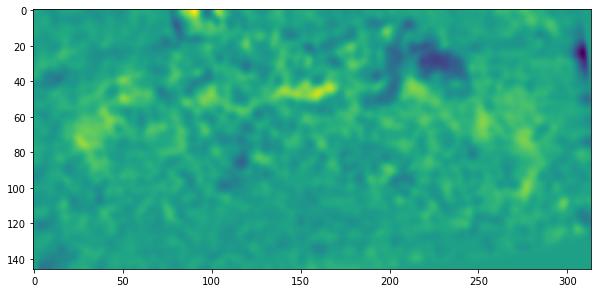

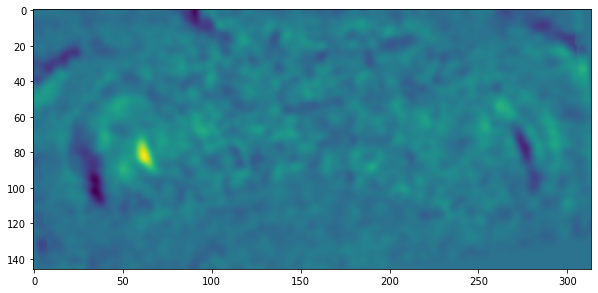

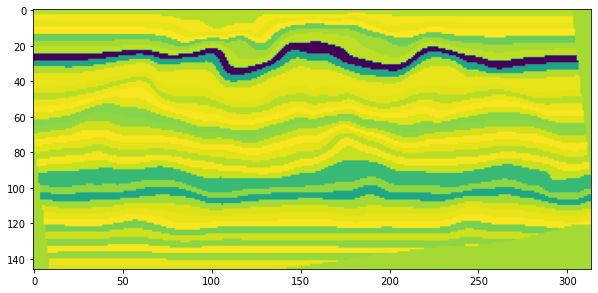

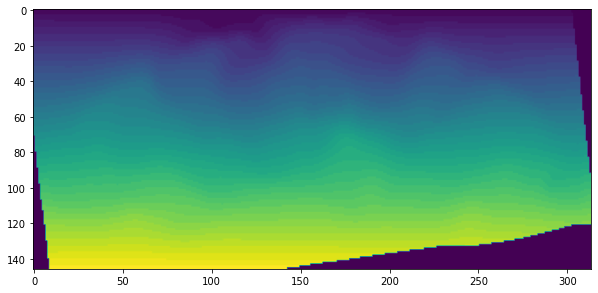

In [6]:
plt.figure(figsize=(10,10))
plt.imshow(np.mean(dff[:,:,20,:], axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(np.nanmean(brain[:,:,20,:], axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(np.nanmax(ts[:,:,20,:], axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(np.nanmax(t[:,:,20,:], axis=-1).T)

In [19]:
partial=dff[...,50,:]
nx, ny, nt = partial.shape
partial_flat=partial.reshape(nx*ny,nt).T
print(np.shape(partial_flat))

(100, 45844)


In [20]:
mean_test=np.mean(partial_flat, axis=0)

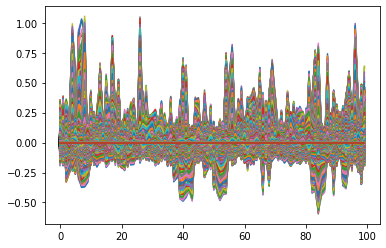

In [21]:
# plt.plot(mean_test);
plt.plot(partial_flat);

In [22]:
def find_most_common_frequency(signal, fs):
    # Compute the FFT of the signal
    fft_result = np.fft.fft(signal)
    
    # Compute the corresponding frequency spectrum
    freqs = np.fft.fftfreq(len(signal), d=1/fs)
    
    # Find the index of the frequency with the highest amplitude
    idx = np.argmax(np.abs(fft_result))
    
    # Get the most common frequency
    most_common_freq = freqs[idx]
    
    return most_common_freq

In [50]:
#bin size is 100ms, there's probs some way to get this out of the data but idk how
T=(t[0,0,0,1]-t[0,0,0,0])/1000
fs_dff=1/T #sample rate, Hz
fs

10.0

In [51]:
%%time
nx, ny, nz, nt = dff.shape
dff_flat=dff.reshape(nx*ny*nz,nt).T
# Compute the most common frequency for each voxel
most_common_frequencies = np.zeros(nx * ny * nz)
for i in range(nx * ny * nz):
    most_common_frequencies[i] = find_most_common_frequency(dff_flat[:,i], fs_dff)

CPU times: user 1min 6s, sys: 906 ms, total: 1min 7s
Wall time: 1min 7s


In [28]:
most_common_frequencies = most_common_frequencies.reshape(nx, ny, nz)
print("Most common frequencies shape:", most_common_frequencies.shape)

Most common frequencies shape: (314, 146, 91)


(0.0, 50.0)

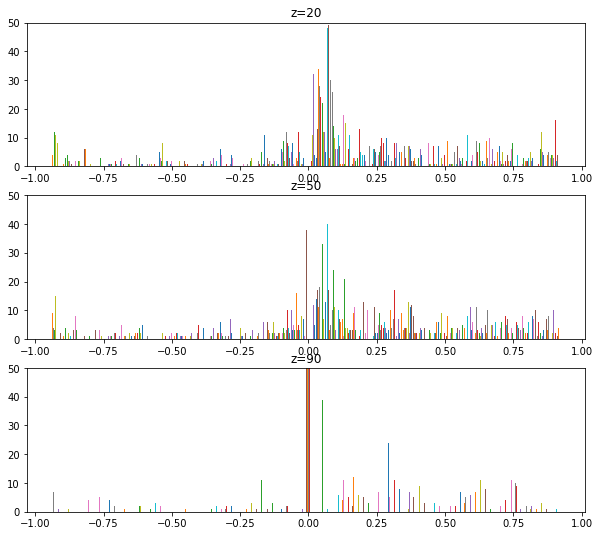

In [33]:
bin_num=100
fig, (ax1, ax2, ax3) = plt.subplots(3, 1,figsize=(10, 9));
ax1 = plt.subplot(311)
ax1_z=20
ax1.hist(most_common_frequencies[...,ax1_z],bins=bin_num);
ax1.set_title(f'z={ax1_z}')
ax1.set_ylim(0,50)
ax2 = plt.subplot(312)
ax2_z=50
ax2.hist(most_common_frequencies[...,ax2_z],bins=bin_num);
ax2.set_title(f'z={ax2_z}')
ax2.set_ylim(0,50)
ax3 = plt.subplot(313)
ax3_z=90
ax3.hist(most_common_frequencies[...,ax3_z],bins=bin_num);
ax3.set_title(f'z={ax3_z}')
ax3.set_ylim(0,50)

In [46]:
#bin size is 100ms, there's probs some way to get this out of the data but idk how
T=100/1000
fs=1/T #sample rate, Hz
fs

10.0

In [47]:
%%time
nx, ny, nz, nt = brain.shape
brain_flat=brain.reshape(nx*ny*nz,nt).T
# Compute the most common frequency for each voxel
most_common_frequencies = np.zeros(nx * ny * nz)
for i in range(nx * ny * nz):
    most_common_frequencies[i] = find_most_common_frequency(brain_flat[:,i], fs)

CPU times: user 5min 35s, sys: 13.7 s, total: 5min 49s
Wall time: 5min 49s


In [48]:
most_common_frequencies = most_common_frequencies.reshape(nx, ny, nz)
print("Most common frequencies shape:", most_common_frequencies.shape)

Most common frequencies shape: (314, 146, 91)


(0.0, 50.0)

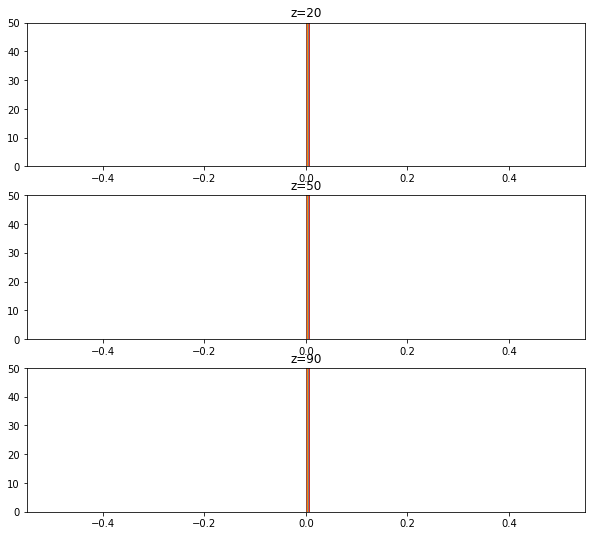

In [49]:
bin_num=100
fig, (ax1, ax2, ax3) = plt.subplots(3, 1,figsize=(10, 9));
ax1 = plt.subplot(311)
ax1_z=20
ax1.hist(most_common_frequencies[...,ax1_z],bins=bin_num);
ax1.set_title(f'z={ax1_z}')
ax1.set_ylim(0,50)
ax2 = plt.subplot(312)
ax2_z=50
ax2.hist(most_common_frequencies[...,ax2_z],bins=bin_num);
ax2.set_title(f'z={ax2_z}')
ax2.set_ylim(0,50)
ax3 = plt.subplot(313)
ax3_z=90
ax3.hist(most_common_frequencies[...,ax3_z],bins=bin_num);
ax3.set_title(f'z={ax3_z}')
ax3.set_ylim(0,50)

In [40]:
f0 = 1.8  # Frequency to be removed from signal (Hz)
Q = 30.0  # Quality factor
w0 = f0/(fs/2)

In [41]:
w0

0.36

In [52]:
%%time
b_notch,a_notch=signal.iirnotch(w0, Q, fs)
responses_notch = signal.filtfilt(b_notch, a_notch, brain, axis=-1)

CPU times: user 59.8 s, sys: 35.2 s, total: 1min 34s
Wall time: 1min 42s


In [53]:
np.shape(responses_notch)

(314, 146, 91, 1039)

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning:

Mean of empty slice

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning:

Mean of empty slice



/home/users/ilanazs/.local/lib/python3.6/site-packages/matplotlib/image.py:446: UserWarning:


/home/users/ilanazs/.local/lib/python3.6/site-packages/matplotlib/image.py:453: UserWarning:


/home/users/ilanazs/.local/lib/python3.6/site-packages/matplotlib/image.py:458: UserWarning:




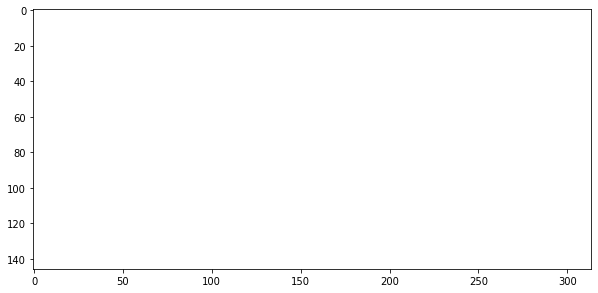

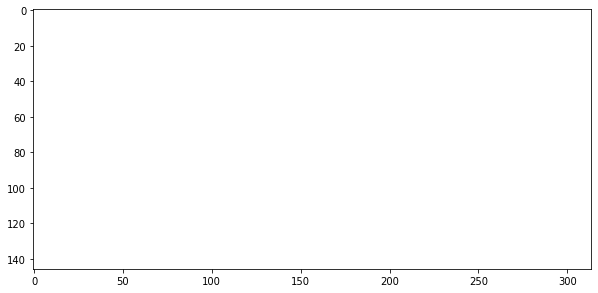

In [54]:
plt.figure(figsize=(10,10))
plt.imshow(np.nanmean(brain[:,:,20,:], axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(np.nanmean(responses_notch[:,:,20,:], axis=-1).T)